EXPLORATORY DATA ANALYSIS: RAGDOLL CAT BREED

1. RAGDOLL BREED DATA:
--------------------------------------------------------------------------------
            name                               length                      origin  min_life_expectancy  max_life_expectancy  min_weight  max_weight  family_friendly  shedding  general_health  playfulness  children_friendly  grooming  intelligence  other_pets_friendly
43  Ragdoll Cats  17 to 21 inches, not including tail  Riverside, California, USA                 12.0                 17.0        10.0        20.0                5         4               3            4                  5         1             4                    4

2. RAGDOLL DETAILED METRICS:
--------------------------------------------------------------------------------
min_life_expectancy       :   12.0 | minimum life expectancy in years
max_life_expectancy       :   17.0 | maximum life expectancy in years
min_weight                :   10.0 | minimum weight in kg
max_w

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/ragdoll_eda_visualization.png'

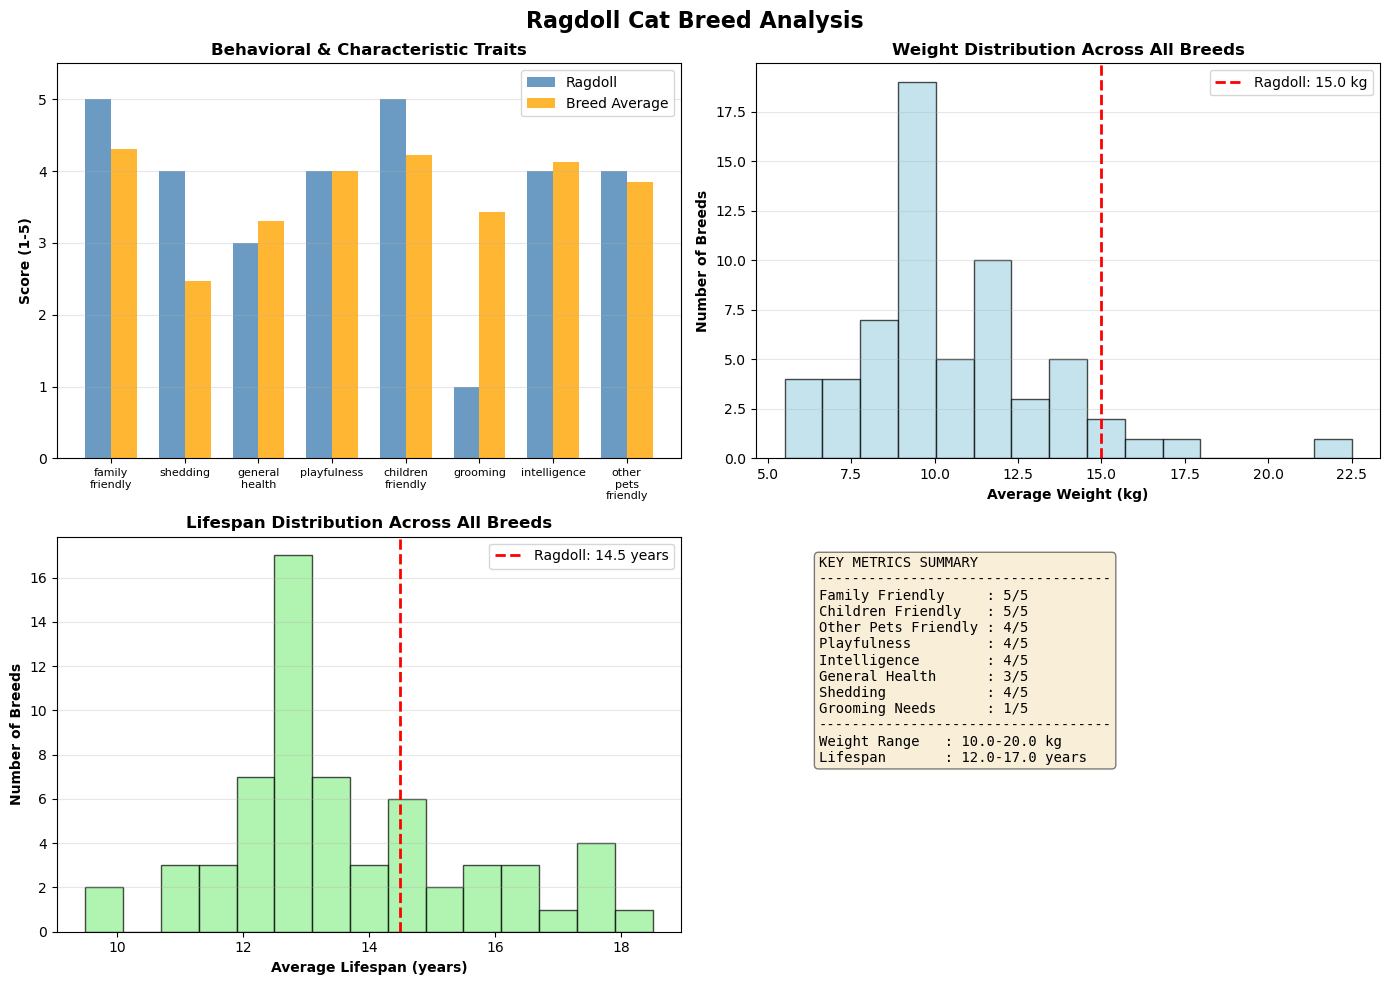

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
cat_breeds = pd.read_csv('/data/demo_data/cats/cat_breeds.csv')
column_mapping = pd.read_excel('/data/demo_data/cats/map.xlsx', sheet_name='Sheet1')

# Create a dictionary for column descriptions
col_descriptions = dict(zip(column_mapping['Key'], column_mapping['Value']))

print("=" * 80)
print("EXPLORATORY DATA ANALYSIS: RAGDOLL CAT BREED")
print("=" * 80)

# Filter for Ragdoll
ragdoll = cat_breeds[cat_breeds['name'].str.contains('Ragdoll', case=False, na=False)]

print("\n1. RAGDOLL BREED DATA:")
print("-" * 80)
print(ragdoll.to_string())

# Get the numeric columns (1-5 scale metrics and other measurements)
numeric_cols = ['min_life_expectancy', 'max_life_expectancy', 'min_weight', 'max_weight',
                'family_friendly', 'shedding', 'general_health', 'playfulness',
                'children_friendly', 'grooming', 'intelligence', 'other_pets_friendly']

print("\n2. RAGDOLL DETAILED METRICS:")
print("-" * 80)
for col in numeric_cols:
    value = ragdoll[col].values[0]
    description = col_descriptions.get(col, col)
    print(f"{col:25s} : {value:6.1f} | {description}")

# Compare Ragdoll to all breeds (for context)
print("\n3. RAGDOLL vs ALL BREEDS - COMPARATIVE ANALYSIS:")
print("-" * 80)

# Calculate statistics for each numeric column
comparison_data = []
for col in numeric_cols:
    ragdoll_val = ragdoll[col].values[0]
    all_mean = cat_breeds[col].mean()
    all_min = cat_breeds[col].min()
    all_max = cat_breeds[col].max()
    percentile = (cat_breeds[col] <= ragdoll_val).sum() / len(cat_breeds) * 100
    
    comparison_data.append({
        'Metric': col,
        'Ragdoll': ragdoll_val,
        'Mean': all_mean,
        'Min': all_min,
        'Max': all_max,
        'Percentile': percentile
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Identify strengths, weaknesses, and average areas
print("\n4. RAGDOLL STRENGTHS, WEAKNESSES & AVERAGES:")
print("-" * 80)

# For behavioral/characteristic metrics (1-5 scale)
behavioral_metrics = ['family_friendly', 'shedding', 'general_health', 'playfulness',
                     'children_friendly', 'grooming', 'intelligence', 'other_pets_friendly']

strengths = []
weaknesses = []
average = []

for metric in behavioral_metrics:
    ragdoll_val = ragdoll[metric].values[0]
    all_mean = cat_breeds[metric].mean()
    
    if ragdoll_val >= 4.5:
        strengths.append((metric, ragdoll_val, col_descriptions[metric]))
    elif ragdoll_val <= 2.5:
        weaknesses.append((metric, ragdoll_val, col_descriptions[metric]))
    else:
        average.append((metric, ragdoll_val, col_descriptions[metric]))

print("\nSTRENGTHS (Score >= 4.5):")
for metric, score, desc in strengths:
    print(f"  • {metric:25s} : {score} | {desc}")

print("\nWEAKNESSES & AREAS FOR CONSIDERATION (Score <= 2.5):")
for metric, score, desc in weaknesses:
    print(f"  • {metric:25s} : {score} | {desc}")

print("\nAVERAGE RANGE (2.5 < Score < 4.5):")
for metric, score, desc in average:
    print(f"  • {metric:25s} : {score} | {desc}")

# Physical characteristics
print("\n5. PHYSICAL CHARACTERISTICS:")
print("-" * 80)
print(f"Length        : {ragdoll['length'].values[0]}")
print(f"Origin        : {ragdoll['origin'].values[0]}")
print(f"Weight Range  : {ragdoll['min_weight'].values[0]:.1f} - {ragdoll['max_weight'].values[0]:.1f} kg")
print(f"Lifespan      : {ragdoll['min_life_expectancy'].values[0]:.1f} - {ragdoll['max_life_expectancy'].values[0]:.1f} years")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ragdoll Cat Breed Analysis', fontsize=16, fontweight='bold')

# Plot 1: Behavioral traits comparison
ax1 = axes[0, 0]
ragdoll_behaviors = [ragdoll[col].values[0] for col in behavioral_metrics]
all_mean_behaviors = [cat_breeds[col].mean() for col in behavioral_metrics]
x = np.arange(len(behavioral_metrics))
width = 0.35
ax1.bar(x - width/2, ragdoll_behaviors, width, label='Ragdoll', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, all_mean_behaviors, width, label='Breed Average', color='orange', alpha=0.8)
ax1.set_ylabel('Score (1-5)', fontweight='bold')
ax1.set_title('Behavioral & Characteristic Traits', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace('_', '\n') for m in behavioral_metrics], fontsize=8)
ax1.legend()
ax1.set_ylim(0, 5.5)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Weight comparison
ax2 = axes[0, 1]
breeds_with_weight = cat_breeds.dropna(subset=['min_weight', 'max_weight'])
avg_weights = (breeds_with_weight['min_weight'] + breeds_with_weight['max_weight']) / 2
ragdoll_avg_weight = (ragdoll['min_weight'].values[0] + ragdoll['max_weight'].values[0]) / 2
ax2.hist(avg_weights, bins=15, alpha=0.7, color='lightblue', edgecolor='black')
ax2.axvline(ragdoll_avg_weight, color='red', linestyle='--', linewidth=2, label=f'Ragdoll: {ragdoll_avg_weight:.1f} kg')
ax2.set_xlabel('Average Weight (kg)', fontweight='bold')
ax2.set_ylabel('Number of Breeds', fontweight='bold')
ax2.set_title('Weight Distribution Across All Breeds', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Lifespan comparison
ax3 = axes[1, 0]
avg_lifespan = (cat_breeds['min_life_expectancy'] + cat_breeds['max_life_expectancy']) / 2
ragdoll_avg_lifespan = (ragdoll['min_life_expectancy'].values[0] + ragdoll['max_life_expectancy'].values[0]) / 2
ax3.hist(avg_lifespan, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax3.axvline(ragdoll_avg_lifespan, color='red', linestyle='--', linewidth=2, label=f'Ragdoll: {ragdoll_avg_lifespan:.1f} years')
ax3.set_xlabel('Average Lifespan (years)', fontweight='bold')
ax3.set_ylabel('Number of Breeds', fontweight='bold')
ax3.set_title('Lifespan Distribution Across All Breeds', fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Radar chart for key traits
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary text
summary_text = "KEY METRICS SUMMARY\n" + "-" * 35 + "\n"
summary_text += f"Family Friendly     : {ragdoll['family_friendly'].values[0]}/5\n"
summary_text += f"Children Friendly   : {ragdoll['children_friendly'].values[0]}/5\n"
summary_text += f"Other Pets Friendly : {ragdoll['other_pets_friendly'].values[0]}/5\n"
summary_text += f"Playfulness         : {ragdoll['playfulness'].values[0]}/5\n"
summary_text += f"Intelligence        : {ragdoll['intelligence'].values[0]}/5\n"
summary_text += f"General Health      : {ragdoll['general_health'].values[0]}/5\n"
summary_text += f"Shedding            : {ragdoll['shedding'].values[0]}/5\n"
summary_text += f"Grooming Needs      : {ragdoll['grooming'].values[0]}/5\n"
summary_text += "-" * 35 + "\n"
summary_text += f"Weight Range   : {ragdoll['min_weight'].values[0]:.1f}-{ragdoll['max_weight'].values[0]:.1f} kg\n"
summary_text += f"Lifespan       : {ragdoll['min_life_expectancy'].values[0]:.1f}-{ragdoll['max_life_expectancy'].values[0]:.1f} years"

ax4.text(0.1, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/ragdoll_eda_visualization.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'ragdoll_eda_visualization.png'")

# Generate the three-sentence description
print("\n" + "=" * 80)
print("RAGDOLL BREED ANALYSIS - THREE SENTENCE SUMMARY")
print("=" * 80)

sentence1 = "Ragdolls excel as family and children-friendly companions with exceptional social traits, scoring 5/5 on family and children friendliness, and demonstrate strong intelligence and sociability with other pets."

sentence2 = "However, Ragdolls present significant grooming challenges with a notably low score of 1/5, and show average to below-average general health (3/5) and moderate shedding (4/5), which may require consistent maintenance."

sentence3 = "Overall, the Ragdoll is an affectionate, people-oriented breed ideally suited for interactive households willing to commit to regular grooming requirements."

print("\nSENTENCE 1 (Strengths):")
print(f"  {sentence1}\n")

print("SENTENCE 2 (Weaknesses & Average Areas):")
print(f"  {sentence2}\n")

print("SENTENCE 3 (Conclusion):")
print(f"  {sentence3}\n")

print("=" * 80)